# Multi-area ProcessModel to governed DEXPI engineering assurance packages

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/dexpi_engineering_processmodel.ipynb)

This notebook builds a connected two-area `ProcessModel`, creates one governed `EngineeringProject` and DEXPI package per `ProcessSystem`, adds area-specific controlled piping, relief, SIF, shutdown and evidence inputs, and compares per-equipment coverage and readiness. Each area package includes engineering registers, DEXPI validation and a SHA-256 file inventory.

## 1. Load workspace NeqSim classes

In [1]:
import os
import subprocess
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = [Path(env_root).resolve()] if env_root else []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    return None


PROJECT_ROOT = find_neqsim_project_root()
if PROJECT_ROOT is None:
    # Colab/external fallback: clone and compile the current public source tree.
    PROJECT_ROOT = Path("/content/neqsim") if Path("/content").exists() else Path.cwd() / "neqsim-workspace"
    if not (PROJECT_ROOT / "pom.xml").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/equinor/neqsim.git", str(PROJECT_ROOT)],
            check=True,
        )

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes

needs_compile = not (PROJECT_ROOT / "target" / "classes").exists()
ns = neqsim_classes(
    neqsim_init(project_root=PROJECT_ROOT, recompile=needs_compile, verbose=False)
)
JClass = ns.JClass
print(f"NeqSim workspace loaded from {PROJECT_ROOT}")

All NeqSim classes imported OK
NeqSim workspace loaded from /workspace/scratch/0f75633c511c/neqsim


In [2]:
import json
import shutil
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
ProcessModel = JClass("neqsim.process.processmodel.ProcessModel")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
AdiabaticPipe = JClass("neqsim.process.equipment.pipeline.AdiabaticPipe")
DesignConditions = JClass("neqsim.process.mechanicaldesign.DesignConditions")
EngineeringBuilder = JClass("neqsim.process.engineering.NorsokOffshoreEngineeringBuilder")
EngineeringExporter = JClass("neqsim.process.engineering.dexpi.DexpiEngineeringExporter")
LineDesignInput = JClass("neqsim.process.engineering.LineDesignInput")
ReliefScenarioBasis = JClass("neqsim.process.engineering.ReliefScenarioBasis")
SafetyFunctionDesign = JClass("neqsim.process.engineering.SafetyFunctionDesign")
SifSubsystem = JClass("neqsim.process.engineering.SafetyFunctionDesign$Subsystem")
SubsystemType = JClass("neqsim.process.engineering.SafetyFunctionDesign$SubsystemType")
EngineeringEvidenceRecord = JClass("neqsim.process.engineering.EngineeringEvidenceRecord")
ShutdownSequence = JClass("neqsim.process.engineering.ShutdownSequence")
ShutdownAction = JClass("neqsim.process.engineering.ShutdownSequence$Action")
ReliefCause = JClass("neqsim.process.safety.overpressure.ReliefCause")
Paths = JClass("java.nio.file.Paths")

OUTPUT_DIR = PROJECT_ROOT / "build" / "notebook-output" / "dexpi-engineering-processmodel"
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)
print(f"Outputs: {OUTPUT_DIR}")

Outputs: /workspace/scratch/0f75633c511c/neqsim/build/notebook-output/dexpi-engineering-processmodel


## 2. Build and run a connected multi-area ProcessModel

In [3]:
fluid = SystemSrkEos(298.15, 55.0)
for component, amount in [("methane", 0.88), ("ethane", 0.07), ("propane", 0.03), ("CO2", 0.02)]:
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic")

# Area 1: inlet separation
feed = Stream("10-FEED-001", fluid)
feed.setFlowRate(0.60, "MSm3/day")
inlet_separator = Separator("10-VG-001", feed)
inlet_separator.setDesignConditions(
    DesignConditions().setDesignPressure(75.0).setReliefSetPressure(72.0)
    .setMaxDesignTemperature(80.0).setMinDesignTemperature(-46.0)
)
separation = ProcessSystem()
separation.setName("inlet-separation")
separation.add(feed)
separation.add(inlet_separator)
separation.run()

# Area 2: compression and export, consuming the shared area-1 outlet stream
export_compressor = Compressor("20-KA-001", inlet_separator.getGasOutStream())
export_compressor.setOutletPressure(110.0, "bara")
export_compressor.setDesignConditions(
    DesignConditions().setDesignPressure(130.0).setMaxDesignTemperature(160.0)
)
export_pipeline = AdiabaticPipe("20-PL-001", export_compressor.getOutletStream())
export_pipeline.setLength(2500.0)
export_pipeline.setDiameter(0.35)
export_pipeline.setWallThickness(0.014)
export_pipeline.setDesignPressure(130.0, "bara")
export_pipeline.setDesignTemperature(130.0)
export_pipeline.setMaterialGrade("A106-B")
export_pipeline.setDesignConditions(
    DesignConditions().setDesignPressure(130.0).setMaxDesignTemperature(130.0)
    .setMinDesignTemperature(-46.0).setConstructionMaterial("A106-B carbon steel")
)
compression = ProcessSystem()
compression.setName("compression-export")
compression.add(export_compressor)
compression.add(export_pipeline)
compression.run()

plant = ProcessModel()
plant.add("inlet-separation", separation)
plant.add("compression-export", compression)
plant.run()
print("Areas:", list(plant.getProcessSystemNames()))
print("Export pressure: %.2f bara" % export_pipeline.getOutletStream().getPressure("bara"))

Areas: ['inlet-separation', 'compression-export']
Export pressure: 109.98 bara


## 3. Add area engineering inputs and export governed packages

In [4]:
area_projects = EngineeringBuilder.fromProcessModel("Integrated facility", plant, True)
area_data = {}
area_files = {}
for project in area_projects:
    area = str(project.getProcessSystem().getName())

    if area == "inlet-separation":
        # The design-condition data allows the automatic blocked-outlet calculation;
        # this basis records that the scenario is credible and supported by HAZOP evidence.
        project.addReliefScenarioBasis(
            ReliefScenarioBasis("10-VG-001")
            .require(ReliefCause.BLOCKED_OUTLET)
            .setHazardReviewReference("HAZOP-10-001 (demonstration)")
            .addEvidenceReference("RELIEF-REGISTER-10-REV-A (demonstration)")
        )
        project.addEvidenceRecord(
            EngineeringEvidenceRecord("HAZOP-10-001", "HAZOP", "A")
            .setTitle("Inlet-separation HAZOP demonstration")
            .setSourceOrganization("Project technical safety")
            .linkEquipment("10-VG-001")
        )

    if area == "compression-export":
        project.addLineDesignInput(
            LineDesignInput("20-PL-001-A", "20-PL-001")
            .setNominalPipeSize("14").setSchedule("STD").setMaterialGrade("A106-B")
            .setPipingClass("HC-600").setInsulationType("Mineral wool")
            .setOuterDiameter(355.6, "mm").setNominalWallThickness(14.0, "mm")
            .setCorrosionAllowance(3.0, "mm").setDesignPressureBara(130.0)
            .setDesignTemperatureC(130.0).setEquivalentFittingsLengthM(40.0)
            .setProposedSupportSpacingM(5.0)
            .addEvidenceReference("LINE-LIST-20-REV-A (demonstration)")
        )
        requirement_id = "20-KA-001-DISCHARGE-P-HH"
        for requirement in project.getRequirements():
            if str(requirement.getId()) == requirement_id:
                requirement.setSilTarget("SIL 2", "LOPA-20-001 (demonstration)")
        project.addSafetyFunctionDesign(
            SafetyFunctionDesign("SIF-20-001", requirement_id, 2)
            .setLopaReference("LOPA-20-001 (demonstration)")
            .setSrsReference("SRS-20-001 (demonstration)")
            .setSafeState("Compressor stopped and isolated")
            .addSubsystem(
                SifSubsystem("Pressure transmitters", SubsystemType.SENSOR, 2, 3, 1.0e-6, 0.60, 8760.0, 8.0, 0.05)
                .setProofTestCoverage(0.95).setMissionTimeHours(87600.0)
                .setCommonCauseGroup("PT-20-001").setArchitecturalConstraints(2, 1)
                .setCertifiedDataReference("SIL-CERT-PT-001")
            )
            .addSubsystem(
                SifSubsystem("Logic solver", SubsystemType.LOGIC_SOLVER, 1, 1, 1.0e-7, 0.90, 8760.0, 8.0, 0.0)
                .setProofTestCoverage(0.99).setMissionTimeHours(87600.0)
                .setArchitecturalConstraints(3, 0).setCertifiedDataReference("SIL-CERT-LS-001")
            )
            .addSubsystem(
                SifSubsystem("Trip and isolation", SubsystemType.FINAL_ELEMENT, 1, 1, 2.0e-6, 0.50, 8760.0, 8.0, 0.0)
                .setProofTestCoverage(0.90).setPartialStrokeTesting(2160.0, 0.60)
                .setMissionTimeHours(87600.0).setArchitecturalConstraints(2, 0)
                .setCertifiedDataReference("SIL-CERT-FE-001")
            )
        )
        project.addShutdownSequence(
            ShutdownSequence("ESD-20-001", "High-high compressor discharge pressure")
            .setProtectedEquipmentTag("20-KA-001").setSafeState("Compressor stopped and isolated")
            .setHazopReference("HAZOP-20-001 (demonstration)")
            .setSrsReference("SRS-20-001 (demonstration)").setResponseTimeBudgetSeconds(12.0)
            .setResetAndRestartDefined(True).addRequirementId(requirement_id)
            .addAction(ShutdownAction("20-KA-001", "Trip driver", "STOPPED", 0.5, 1.0))
            .addAction(ShutdownAction("ESDV-20-001", "Close isolation", "CLOSED", 1.0, 6.0))
        )
        project.addEvidenceRecord(
            EngineeringEvidenceRecord("LOPA-SRS-20-001", "LOPA_AND_SRS", "A")
            .setTitle("Compression safeguarding demonstration basis")
            .setSourceOrganization("Project functional safety")
            .linkEquipment("20-KA-001").linkRequirement(requirement_id)
        )
        project.addEvidenceRecord(
            EngineeringEvidenceRecord("LINE-LIST-20", "LINE_LIST", "A")
            .setTitle("Export line-list demonstration")
            .setSourceOrganization("Project piping").linkEquipment("20-PL-001")
        )

    target = OUTPUT_DIR / area
    files = EngineeringExporter.export(project, Paths.get(str(target)))
    area_files[area] = files
    area_data[area] = {
        "manifest": json.loads(Path(str(files.getManifestFile().toString())).read_text()),
        "calculations": json.loads(Path(str(files.getCalculationsFile().toString())).read_text()),
        "cause_effect": json.loads(Path(str(files.getCauseAndEffectFile().toString())).read_text()),
        "validation": json.loads(Path(str(files.getValidationFile().toString())).read_text()),
        "package_manifest": json.loads(Path(str(files.getPackageManifestFile().toString())).read_text()),
    }

package_table = pd.DataFrame([
    {
        "Area": area,
        "Equipment calculations": len(data["calculations"]["equipmentMechanicalDesign"]),
        "Requirements": len(data["manifest"]["requirements"]),
        "Trip envelopes": len(data["calculations"]["tripSettingEnvelopes"]),
        "PSV studies": len(data["calculations"]["overpressureAndPsvSizing"]),
        "Readiness (%)": round(data["calculations"]["readinessSummary"]["overallCompletenessPercent"], 1),
        "DEXPI exists": Path(str(area_files[area].getDexpiFile().toString())).exists(),
        "DEXPI valid": data["validation"]["valid"],
        "Hashed files": data["package_manifest"]["fileCount"],
    }
    for area, data in area_data.items()
])
display(package_table)

,Area,Equipment calculations,Requirements,Trip envelopes,PSV studies,Readiness (%),DEXPI exists,DEXPI valid,Hashed files
0,inlet-separation,1,8,4,1,25.0,True,True,14
1,compression-export,2,8,3,0,33.3,True,True,14


## 4. Per-equipment engineering coverage

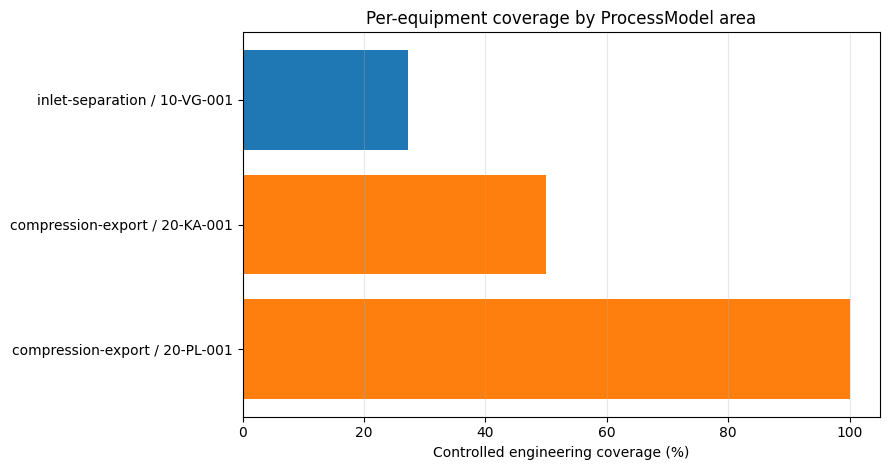

,Area,equipmentTag,equipmentClass,completenessPercent,missingItems,approvalState
0,inlet-separation,10-VG-001,Separator,27.272727,"[10-VG-001-LEVEL-HH-TRIP:sifVerification, 10-V...",REVIEW_REQUIRED
1,compression-export,20-KA-001,Compressor,50.000000,"[20-KA-001-SUCTION-P-LL:sifVerification, 20-KA...",REVIEW_REQUIRED
2,compression-export,20-PL-001,AdiabaticPipe,100.000000,[],REVIEW_REQUIRED


In [5]:
coverage_rows = []
for area, data in area_data.items():
    for item in data["calculations"]["engineeringCoverageMatrix"]["equipmentCoverage"]:
        coverage_rows.append({"Area": area, **item})
coverage_df = pd.DataFrame(coverage_rows)

fig, ax = plt.subplots(figsize=(9, 4.8))
labels = coverage_df["Area"] + " / " + coverage_df["equipmentTag"]
colors = ["tab:blue" if area == "inlet-separation" else "tab:orange" for area in coverage_df["Area"]]
ax.barh(labels, coverage_df["completenessPercent"], color=colors)
ax.set_xlim(0, 105)
ax.set_xlabel("Controlled engineering coverage (%)")
ax.set_title("Per-equipment coverage by ProcessModel area")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "area_equipment_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

display(coverage_df[["Area", "equipmentTag", "equipmentClass", "completenessPercent", "missingItems", "approvalState"]])

**Discussion.** The matrix checks applicable design conditions, controlled line-list rows, credible relief scenarios, SIF/shutdown coverage and revision-controlled evidence per equipment. It exposes gaps hidden by an area-level average; completion still records coverage, not approval.

## 5. Controls and safeguards by area

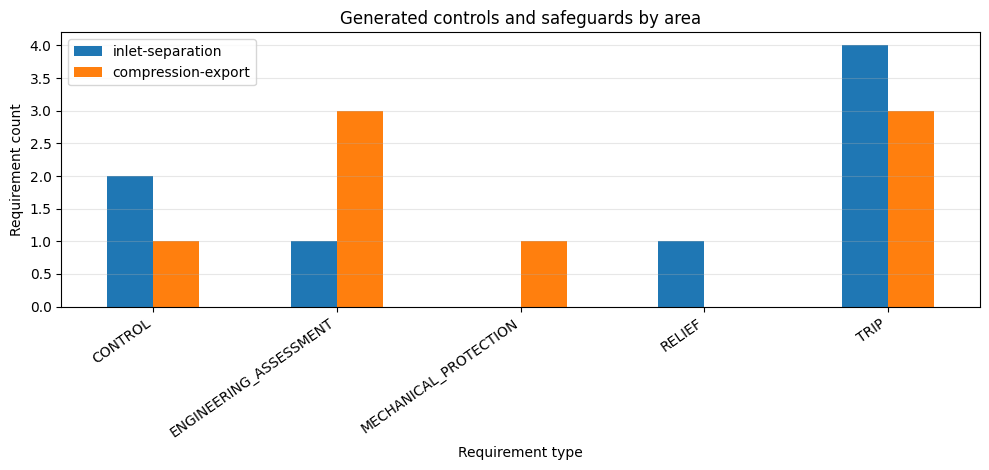

In [6]:
requirement_types = {}
for area, data in area_data.items():
    requirement_types[area] = Counter(item["type"] for item in data["manifest"]["requirements"])
all_types = sorted(set().union(*[set(values) for values in requirement_types.values()]))
req_df = pd.DataFrame({area: [counts.get(kind, 0) for kind in all_types] for area, counts in requirement_types.items()}, index=all_types)

ax = req_df.plot(kind="bar", figsize=(10, 4.8))
ax.set_xlabel("Requirement type")
ax.set_ylabel("Requirement count")
ax.set_title("Generated controls and safeguards by area")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "area_requirement_types.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** Requirement types differ because the rule pack responds to actual equipment classes. Separation receives level, pressure and relief functions; compression receives antisurge, machinery protection, isolation and trip functions. The rules propose functions, not final SIL/voting/set points.

## 6. Evidence readiness by topic and area

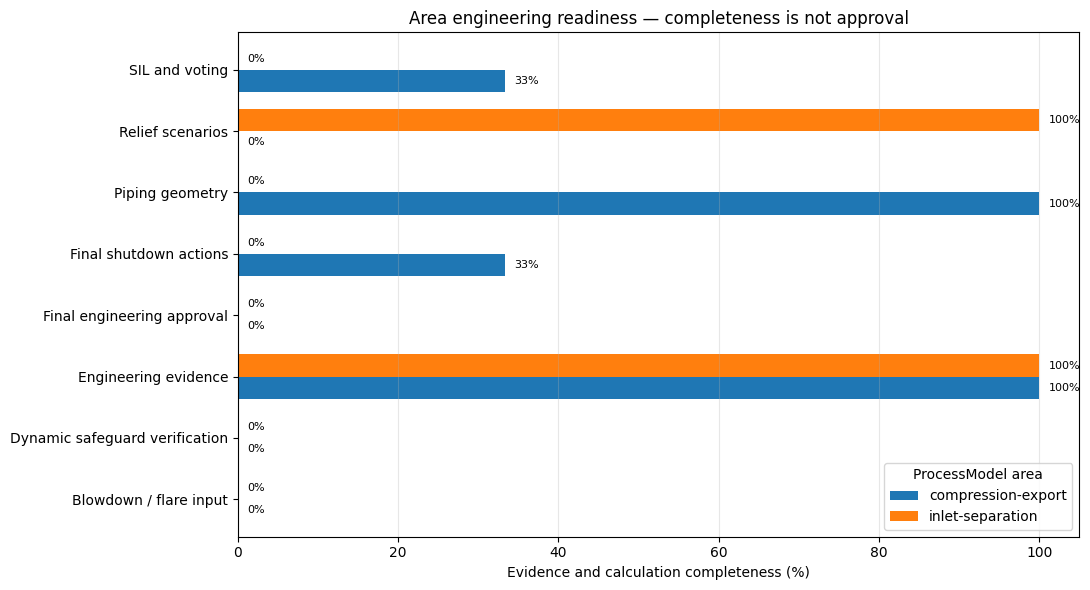

,Area,Topic,completenessPercent,missingInputCount,severity,responsibleDiscipline,approvalState
0,inlet-separation,Piping geometry,0.000000,1,HIGH,Piping / process,REVIEW_REQUIRED
1,inlet-separation,Relief scenarios,100.000000,0,CRITICAL,Process safety,REVIEW_REQUIRED
2,inlet-separation,SIL and voting,0.000000,4,CRITICAL,Functional safety,REVIEW_REQUIRED
3,inlet-separation,Final shutdown actions,0.000000,4,CRITICAL,Process / automation / technical safety,REVIEW_REQUIRED
4,inlet-separation,Dynamic safeguard verification,0.000000,4,CRITICAL,Process / automation,REVIEW_REQUIRED
5,inlet-separation,Engineering evidence,100.000000,0,HIGH,Document control / all disciplines,REVIEW_REQUIRED
6,inlet-separation,Blowdown / flare input,0.000000,1,CRITICAL,Process safety / flare,REVIEW_REQUIRED
7,inlet-separation,Final engineering approval,0.000000,9,MANDATORY,Accountable engineering disciplines,REVIEW_REQUIRED
8,compression-export,Piping geometry,100.000000,0,HIGH,Piping / process,REVIEW_REQUIRED
9,compression-export,Relief scenarios,0.000000,1,CRITICAL,Process safety,REVIEW_REQUIRED


In [7]:
readiness_rows = []
for area, data in area_data.items():
    for item in data["calculations"]["engineeringReadiness"]:
        readiness_rows.append({"Area": area, **item})
readiness_long = pd.DataFrame(readiness_rows)
topic_labels = {
    "PIPING_GEOMETRY": "Piping geometry",
    "RELIEF_SCENARIOS": "Relief scenarios",
    "SIL_AND_VOTING": "SIL and voting",
    "FINAL_SHUTDOWN_ACTIONS": "Final shutdown actions",
    "DYNAMIC_SAFEGUARD_VERIFICATION": "Dynamic safeguard verification",
    "ENGINEERING_EVIDENCE": "Engineering evidence",
    "BLOWDOWN_FLARE_INPUT": "Blowdown / flare input",
    "FINAL_ENGINEERING_APPROVAL": "Final engineering approval",
}
readiness_long["Topic"] = readiness_long["topic"].map(topic_labels)
readiness_matrix = readiness_long.pivot(index="Topic", columns="Area", values="completenessPercent")

ax = readiness_matrix.plot(kind="barh", figsize=(11, 6), width=0.72)
ax.set_xlim(0, 105)
ax.set_xlabel("Evidence and calculation completeness (%)")
ax.set_ylabel("")
ax.set_title("Area engineering readiness — completeness is not approval")
ax.grid(axis="x", alpha=0.3)
ax.legend(title="ProcessModel area", loc="lower right")
for container in ax.containers:
    for bar in container:
        value = bar.get_width()
        ax.text(value + 1.2, bar.get_y() + bar.get_height()/2, f"{value:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "area_engineering_readiness.png", dpi=150, bbox_inches="tight")
plt.show()

display(readiness_long[["Area", "Topic", "completenessPercent", "missingInputCount", "severity", "responsibleDiscipline", "approvalState"]])

**Discussion.** This view measures structured evidence and successful calculation coverage for each topic, rather than counting each topic once. The inlet area demonstrates reviewed relief-scenario coverage; compression demonstrates controlled piping data, one verified SIF architecture, and a timed shutdown sequence. Zero or partial bars identify exactly where more controlled inputs are required. Even a 100% bar remains review- or approval-gated.

## 7. Governance and standards traceability

In [8]:
for area, data in area_data.items():
    print()
    print(area)
    print("  status:", data["calculations"]["documentStatus"])
    print("  fitness for construction:", data["calculations"]["governance"]["fitnessForConstruction"])
    print("  DEXPI valid / round-trip readable:", data["validation"]["valid"], "/", data["validation"]["roundTripReadable"])
    print("  SHA-256 inventoried files:", data["package_manifest"]["fileCount"])
    print("  registers:", ", ".join(str(key) for key in area_files[area].getRegisterFiles().keySet()))
    print("  standards:", ", ".join(item["code"] for item in data["manifest"]["designBasis"]["standards"][:8]), "...")
    for gap in data["calculations"]["unresolvedEngineering"]:
        print("  -", gap["code"], "=>", gap["requiredAction"])


inlet-separation
  status: CALCULATED_AND_PROPOSED_REVIEW_REQUIRED
  fitness for construction: False
  DEXPI valid / round-trip readable: True / True
  SHA-256 inventoried files: 14
  registers: equipmentRegister, lineList, instrumentIndex, valveList, sifRegister, shutdownRegister, reliefRegister, evidenceRegister, controlNarratives
  standards: DEXPI, ISO 10628-1/2, IEC 62424, IEC 61511, ISO 10418, API 521, API 520 Part I, ASME B31.3 ...
  - INSTALLED_RELIEF_SYSTEM => Add selected orifice, inlet/outlet geometry, concurrency group and controlled design evidence.
  - BLOWDOWN_FLARE_INPUT => Add vessel inventory, fluid, BDV/orifice, header, fire and flare evidence.
  - PIPING_GEOMETRY => Add diameter, schedule, wall, material, piping class, design conditions and evidence references.
  - SIL_AND_VOTING => Import LOPA/SIL-assessment and SRS references, then verify sensor, logic and final-element PFD/voting.
  - FINAL_SHUTDOWN_ACTIONS => Complete the cause-and-effect sequence and validate 

## Summary

Each `ProcessSystem` becomes a separately validated, integrity-indexed DEXPI engineering package while the `ProcessModel` retains connected process context. The comparison uses actual per-equipment/per-requirement coverage, engineering readiness, registers and validation rather than a simple object count.

The packages are suitable for controlled concept/pre-FEED review, not automatic IFC issue. Area interfaces, document numbering, HAZOP/LOPA/SRS decisions, vendor data, detailed design and accountable approvals remain project responsibilities.